# Credit Risk: Predicting Loan Defaults
### A beginner-friendly machine learning project in Python

In this project, I build a machine learning model to predict whether a credit card customer will default on their loan payment next month. 

**The Business Problem:**
When people apply for loans or use credit cards:
- If a bank lends money to someone who doesn't pay it back (default), the bank loses that money.
- If a bank rejects someone who would have paid it back, the bank misses out on interest income.

My goal is to use historical customer data (credit limits, payment history, bill amounts) to predict who is likely to default so the lender can make better approval decisions.


In [5]:
# Importing the standard libraries I need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


## 1. Loading the Data
I am using the **UCI Default of Credit Card Clients** dataset, which contains 30,000 customers with demographic info and 6 months of billing and repayment records.


In [6]:
# Load the dataset
df = pd.read_csv('data/UCI_Credit_Card.csv')

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset Shape: 30000 rows, 25 columns


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 2. Data Cleaning
I noticed a few things to clean up:
1. The `ID` column is just a row counter, so I drop it.
2. In the original data, the repayment column for the latest month is named `PAY_0`, but the others are `PAY_2`, `PAY_3`, etc. I rename `PAY_0` to `PAY_1` so it is easier to follow.
3. I rename `default payment next month` to `default` to keep code concise.
4. In `EDUCATION`, values 0, 5, and 6 are undocumented/unknown categories. I group them into category 4 ('others').
5. In `MARRIAGE`, value 0 is unknown. I group it into category 3 ('others').


In [7]:
# Drop ID
if 'ID' in df.columns:
    df = df.drop(columns=['ID'])

# Rename columns for clarity
df = df.rename(columns={
    'PAY_0': 'PAY_1',
    'default payment next month': 'default'
})

# Clean undocumented categories
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

# Check for missing values
print("Missing values in any column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nThere are zero missing values in this dataset!")


Missing values in any column:
Series([], dtype: int64)

There are zero missing values in this dataset!


## 3. Exploratory Data Analysis (EDA)

### Target Class Imbalance
Before doing any modeling, I need to check how many people actually defaulted versus paid.


default
0    23364
1     6636
Name: count, dtype: int64

Percentages:
default
0    77.88
1    22.12
Name: proportion, dtype: float64


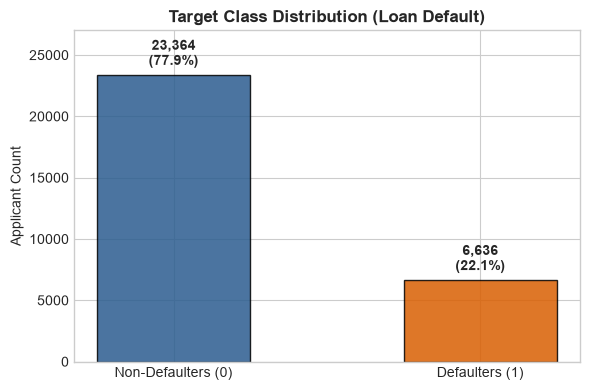

In [8]:
# Check target class distribution
counts = df['default'].value_counts()
print(counts)
print("\nPercentages:")
print(df['default'].value_counts(normalize=True) * 100)

# Plot class balance
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Non-Defaulters (0)', 'Defaulters (1)'], counts, color=['#2b5c8f', '#d95f02'], width=0.5, edgecolor='black', alpha=0.85)

for bar in bars:
    y = bar.get_height()
    pct = (y / len(df)) * 100
    ax.text(bar.get_x() + bar.get_width()/2.0, y + 500, f'{y:,}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')

ax.set_title('Target Class Distribution (Loan Default)', fontsize=12, fontweight='bold')
ax.set_ylabel('Applicant Count')
ax.set_ylim(0, 27000)
plt.tight_layout()
plt.savefig('figures/class_imbalance.png', dpi=200)
plt.show()


**What I noticed about the target:**
About 78% of applicants paid their bills on time, while only 22% defaulted. This means the dataset is **imbalanced** (~3.5 to 1). 
If I don't address this, a lazy model could just predict 'no default' for every single person and still get 78% accuracy, while being completely useless for risk management. To fix this, I will use `class_weight='balanced'` when training my models.


### Looking at Key Features: Credit Limit and Past Due History
Let's see how credit limits and recent late payments compare between defaulters and non-defaulters.


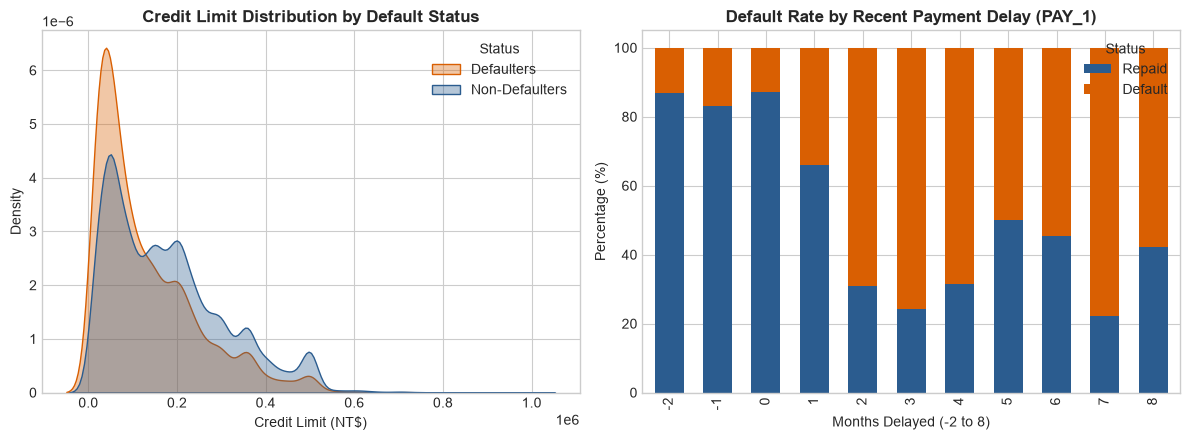

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot 1: Credit Limit
sns.kdeplot(data=df, x='LIMIT_BAL', hue='default', common_norm=False, palette=['#2b5c8f', '#d95f02'],
            fill=True, alpha=0.35, ax=ax1)
ax1.set_title('Credit Limit Distribution by Default Status', fontweight='bold')
ax1.set_xlabel('Credit Limit (NT$)')
ax1.legend(labels=['Defaulters', 'Non-Defaulters'], title='Status')

# Plot 2: Recent Payment Delay (PAY_1)
pay_crosstab = pd.crosstab(df['PAY_1'], df['default'], normalize='index') * 100
pay_crosstab.plot(kind='bar', stacked=True, color=['#2b5c8f', '#d95f02'], ax=ax2, width=0.6)
ax2.set_title('Default Rate by Recent Payment Delay (PAY_1)', fontweight='bold')
ax2.set_xlabel('Months Delayed (-2 to 8)')
ax2.set_ylabel('Percentage (%)')
ax2.legend(labels=['Repaid', 'Default'], title='Status')

plt.tight_layout()
plt.savefig('figures/features_distribution.png', dpi=200)
plt.show()


**Observations:**
1. **Credit Limit**: Defaulters tend to have lower credit limits on average compared to people who repay on time.
2. **Payment Delays**: In `PAY_1`, customers who were delayed by 2 or more months (`PAY_1 >= 2`) have default rates above 50%. A history of late payments is a huge red flag.


### Correlation Heatmap
Let's check the linear correlation between some key financial features and the default target.


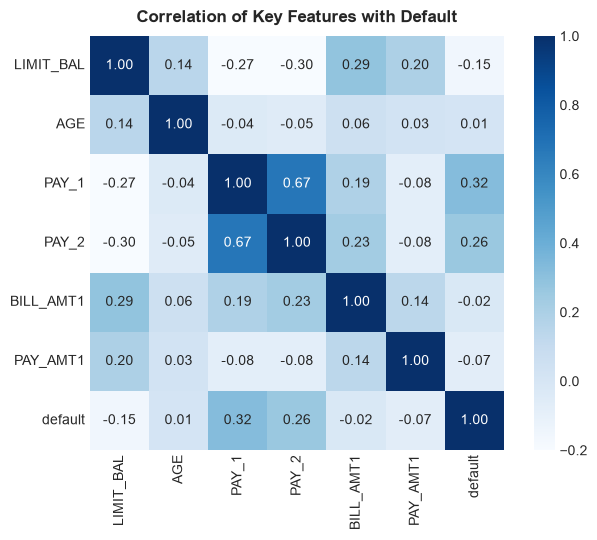

In [10]:
key_cols = ['LIMIT_BAL', 'AGE', 'PAY_1', 'PAY_2', 'BILL_AMT1', 'PAY_AMT1', 'default']
corr = df[key_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', vmin=-0.2, vmax=1.0, square=True, ax=ax)
ax.set_title('Correlation of Key Features with Default', fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('figures/correlation_heatmap.png', dpi=200)
plt.show()


**Observations:**
- `PAY_1` and `PAY_2` have the strongest positive correlation with default (~0.32 and ~0.26). This confirms that recent missed payments are the best single clue that someone might default again.
- `LIMIT_BAL` has a mild negative correlation with default (-0.15), meaning higher credit limits correlate with lower default risk.


## 4. Train / Test Split
I split the data into 80% for training (24,000 customers) and 20% for testing (6,000 customers).
I use `stratify=y` to make sure both the training set and test set have the exact same 22% default proportion.


In [11]:
X = df.drop(columns=['default'])
y = df['default']

# 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set: {X_test.shape[0]} rows")


Training set: 24000 rows
Testing set: 6000 rows


### Feature Scaling
Logistic Regression needs scaled numeric features so that large dollar amounts (like a NT$100,000 credit limit) don't overpower small numbers (like age or payment codes). 
Random Forest does not need scaled features because decision trees only look at splits on individual features one at a time.


In [12]:
# I fit the scaler ONLY on training data to avoid data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 5. Model Training
I train two classic classification models:
1. **Logistic Regression**: A simple, interpretable baseline model.
2. **Random Forest**: An ensemble of decision trees that can capture non-linear relationships. I set `max_depth=6` to keep the trees from overfitting.

Both models use `class_weight='balanced'` so they pay equal attention to the minority defaulter class.


In [13]:
# 1. Train Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# 2. Train Random Forest (max_depth=6)
rf = RandomForestClassifier(n_estimators=100, max_depth=6, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

print("Both models trained successfully!")


Both models trained successfully!


## 6. Model Evaluation
I evaluate both models on the held-out test set (6,000 rows) at the standard 0.5 probability threshold.
I calculate:
- **Accuracy**: Total correct predictions over total applicants.
- **Precision**: When the model predicts default, how often is it right?
- **Recall**: Out of all actual defaulters, how many did the model catch?
- **F1-score**: The balance between Precision and Recall.
- **ROC-AUC**: How well the model ranks defaulters higher than non-defaulters across all possible thresholds.


In [14]:
# Predictions
lr_preds = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

# Build comparison table
models_eval = {
    'Logistic Regression': (y_test, lr_preds, lr_probs),
    'Random Forest': (y_test, rf_preds, rf_probs)
}

results = []
for name, (y_true, y_p, y_pr) in models_eval.items():
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_true, y_p), 4),
        'Precision': round(precision_score(y_true, y_p), 4),
        'Recall': round(recall_score(y_true, y_p), 4),
        'F1-score': round(f1_score(y_true, y_p), 4),
        'ROC-AUC': round(roc_auc_score(y_true, y_pr), 4)
    })

res_df = pd.DataFrame(results)
print("=== Final Model Comparison (Test Set, N=6,000) ===")
print(res_df.to_string(index=False))
res_df


=== Final Model Comparison (Test Set, N=6,000) ===
              Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
Logistic Regression    0.6795     0.3671  0.6202    0.4612   0.7084
      Random Forest    0.7780     0.4984  0.5848    0.5381   0.7713


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.6795,0.3671,0.6202,0.4612,0.7084
1,Random Forest,0.7780,0.4984,0.5848,0.5381,0.7713


### Analysis of Model Results
- **Random Forest** performed significantly better overall, achieving an **Accuracy of 77.8%** and an **ROC-AUC of 0.7713** (compared to 68.0% and 0.7084 for Logistic Regression).
- **Precision** for Random Forest is **49.8%**, meaning when it predicts an applicant will default, it is right half the time.
- **Recall** is **58.5%**, meaning it catches nearly 6 out of 10 actual defaulters at the standard 0.5 cutoff.
- Logistic Regression had slightly higher recall (62.0%), but much lower precision (36.7%), because it falsely flagged a lot of good borrowers.


### ROC Curve Comparison
The ROC curve plots the True Positive Rate (defaulters caught) against the False Positive Rate (good borrowers wrongly flagged). A curve closer to the top-left corner is better.


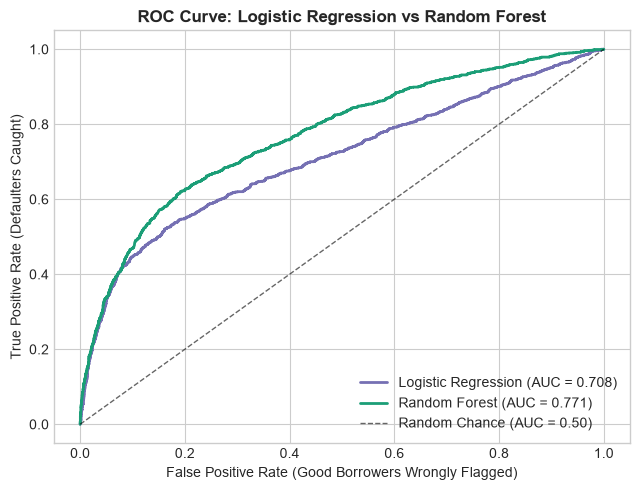

In [15]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
auc_lr = roc_auc_score(y_test, lr_probs)
auc_rf = roc_auc_score(y_test, rf_probs)

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', color='#7570b3', lw=2)
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='#1b9e77', lw=2)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6, label='Random Chance (AUC = 0.50)')
ax.set_title('ROC Curve: Logistic Regression vs Random Forest', fontweight='bold')
ax.set_xlabel('False Positive Rate (Good Borrowers Wrongly Flagged)')
ax.set_ylabel('True Positive Rate (Defaulters Caught)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('figures/roc_curve.png', dpi=200)
plt.show()


## 7. What Features Matter Most? (Feature Importance)
Decision tree models like Random Forest have a built-in `feature_importances_` attribute. It tells us how much each feature contributed to reducing uncertainty when making split decisions.


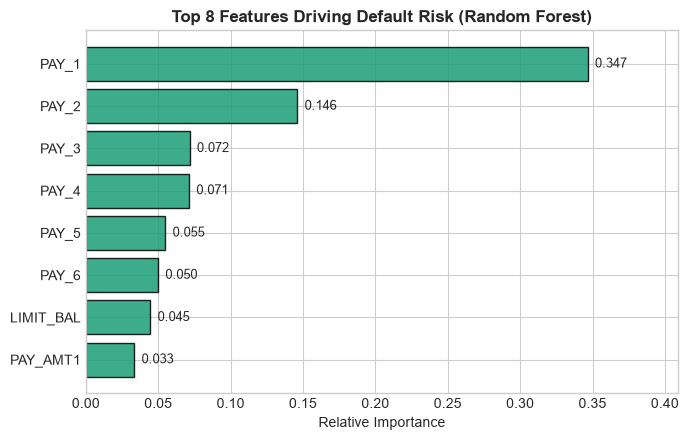

In [16]:
# Extract feature importances
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
top8 = feat_imp.tail(8)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.barh(top8.index, top8.values, color='#1b9e77', alpha=0.85, edgecolor='black')
ax.set_title('Top 8 Features Driving Default Risk (Random Forest)', fontweight='bold')
ax.set_xlabel('Relative Importance')
for bar in bars:
    val = bar.get_width()
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2.0, f'{val:.3f}', va='center', fontsize=9)
ax.set_xlim(0, max(top8.values) * 1.18)
plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=200)
plt.show()


**Plain English Takeaway:**
1. **`PAY_1` (Recent payment delay)** is by far the most important feature (relative importance = ~0.35). If someone was late on their very last bill, that is the biggest clue they will default again.
2. **`PAY_2` through `PAY_6` (Past payment history)** make up the next biggest group of features. A repeated pattern of late payments across multiple months signals high default risk.
3. **`LIMIT_BAL` (Credit Limit)** is also important: borrowers granted lower credit limits historically default more frequently than those with high credit limits.


## 8. Business Note on the Decision Threshold
In this notebook, I evaluated predictions using the standard **0.50 threshold** (if probability >= 0.50, predict default).

In a real lending business, management could decide to lower or raise this threshold:
- If the lender is very risk-averse, they could **lower the threshold** (for example, to 0.35 or 0.40). This would catch more defaulters before lending to them, but it would also wrongly decline more good borrowers.
- If the lender wants to grow fast and accept more loans, they could **raise the threshold**, accepting more risk of defaults in exchange for approving more customers.


## 9. Summary
- **Data**: 30,000 credit records with a 22.1% default rate.
- **Handling Imbalance**: I used `class_weight='balanced'` so the models didn't ignore defaulters.
- **Models**: Random Forest (`max_depth=6`) beat Logistic Regression with **77.8% Accuracy** and **0.7713 ROC-AUC**.
- **Key Insight**: Historical payment delays (`PAY_1`, `PAY_2`) are the primary driver of credit default risk.
